In [33]:
import pandas as pd

kdd_df = pd.read_csv('kdd_train.csv')

cic_df = pd.read_csv('02-14-2018.csv')

print("NSL-KDD Shape:", kdd_df.shape)
print("CIC-IDS2018 Shape:", cic_df.shape)

NSL-KDD Shape: (125973, 42)
CIC-IDS2018 Shape: (447304, 80)


In [34]:
import pandas as pd

kdd_clean = pd.read_csv('kdd_train.csv')

kdd_clean.dropna(inplace=True)


print("Full DataFrame head:")
print(kdd_clean.head())

print("\nLast column head:")
print(kdd_clean.iloc[:, -1].head())

print("\nUnique values in the last column:")
print(kdd_clean.iloc[:, -1].unique())

Full DataFrame head:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10       

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

cic_clean = pd.read_csv('02-14-2018.csv')

cic_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
cic_clean.dropna(inplace=True)

numeric_cols = cic_clean.select_dtypes(include=['float64', 'int64']).columns
target_col = 'Label'

if target_col in numeric_cols:
    numeric_cols = numeric_cols.drop(target_col)

scaler = StandardScaler()
cic_clean[numeric_cols] = scaler.fit_transform(cic_clean[numeric_cols])

print("Scaling successful!")
print(cic_clean.head())

Scaling successful!
   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0 -0.161024 -2.808720  14/02/2018 08:31:01       0.059996     -0.157509   
1 -0.161024 -2.808720  14/02/2018 08:33:50       0.059996     -0.157509   
2 -0.161024 -2.808720  14/02/2018 08:36:39       0.059994     -0.157509   
3 -0.158021 -0.206139  14/02/2018 08:40:13       0.004981      0.436689   
4 -0.158021 -0.206139  14/02/2018 08:40:23       0.006199      0.387173   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0     -0.131444        -0.021983        -0.020668        -0.516450   
1     -0.131444        -0.021983        -0.020668        -0.516450   
2     -0.131444        -0.021983        -0.020668        -0.516450   
3      0.082229         0.029501         0.013779         1.901725   
4      0.103597         0.025512         0.012809         1.901725   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0        -0.182436  ...         -3.980

In [36]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

cic_ml = cic_clean.drop(columns=['Timestamp']).copy()

cic_ml['Label'] = cic_ml['Label'].apply(lambda x: 0 if str(x).strip().lower() == 'benign' else 1)

cic_ml['Label'] = cic_ml['Label'].astype(int)

X = cic_ml.drop(columns=['Label'])
y = cic_ml['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Isolation Forest...")

X_train_benign = X_train[y_train == 0]

iso_forest = IsolationForest(random_state=42, contamination=0.05)
iso_forest.fit(X_train_benign)

iso_preds = iso_forest.predict(X_test)

iso_preds_mapped = [0 if pred == 1 else 1 for pred in iso_preds]

print("Isolation Forest training and prediction successful!")

Training Isolation Forest...
Isolation Forest training and prediction successful!


In [37]:

print("Training Random Forest...")

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("\n--- Isolation Forest Results ---")
print(classification_report(y_test, iso_preds_mapped))

print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_preds))

Training Random Forest...

--- Isolation Forest Results ---
              precision    recall  f1-score   support

           0       0.14      0.95      0.25     13410
           1       0.00      0.00      0.00     75962

    accuracy                           0.14     89372
   macro avg       0.07      0.48      0.12     89372
weighted avg       0.02      0.14      0.04     89372


--- Random Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13410
           1       1.00      1.00      1.00     75962

    accuracy                           1.00     89372
   macro avg       1.00      1.00      1.00     89372
weighted avg       1.00      1.00      1.00     89372



--- Isolation Forest Metrics ---
True Negatives (Correctly identified Benign): 12744
False Positives (Benign flagged as Attack!): 666
False Negatives (Attacks missed): 75962
True Positives (Attacks caught): 0
False Positive Rate (FPR): 0.0497 (4.97%)



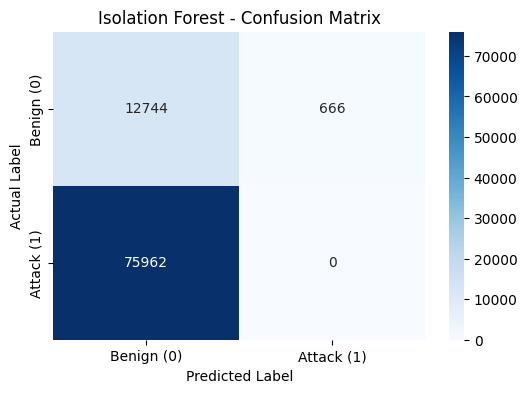

--- Random Forest Metrics ---
True Negatives (Correctly identified Benign): 13410
False Positives (Benign flagged as Attack!): 0
False Negatives (Attacks missed): 0
True Positives (Attacks caught): 75962
False Positive Rate (FPR): 0.0000 (0.00%)



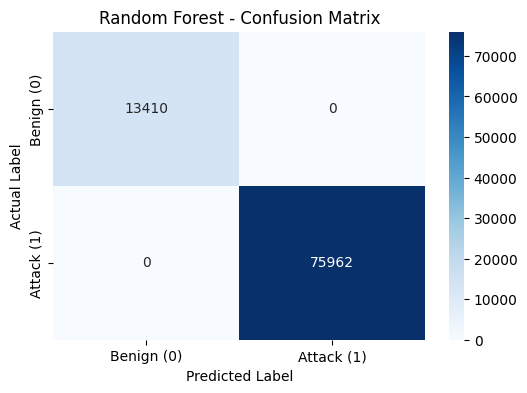

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_and_plot(y_true, y_pred, model_name):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print(f"--- {model_name} Metrics ---")
    print(f"True Negatives (Correctly identified Benign): {tn}")
    print(f"False Positives (Benign flagged as Attack!): {fp}")
    print(f"False Negatives (Attacks missed): {fn}")
    print(f"True Positives (Attacks caught): {tp}")
    print(f"False Positive Rate (FPR): {fpr:.4f} ({fpr*100:.2f}%)\n")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Attack (1)'],
                yticklabels=['Benign (0)', 'Attack (1)'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluate_and_plot(y_test, iso_preds_mapped, "Isolation Forest")
evaluate_and_plot(y_test, rf_preds, "Random Forest")

In [39]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

kdd_ml = pd.get_dummies(kdd_clean, columns=['protocol_type', 'service', 'flag'])

kdd_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
kdd_ml.dropna(inplace=True)

X = kdd_ml.drop(columns=['labels'])

kdd_ml['labels'] = kdd_ml['labels'].apply(lambda x: 0 if str(x).strip().lower() in ['normal', 'benign'] else 1)

y = kdd_ml['labels'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_benign = X_train[y_train == 0]

print("Training Isolation Forest...")
iso_forest = IsolationForest(random_state=42, contamination=0.05)
iso_forest.fit(X_train_benign)
iso_preds = iso_forest.predict(X_test)
iso_preds_mapped = [0 if pred == 1 else 1 for pred in iso_preds]

print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- Isolation Forest Results ---")
print(classification_report(y_test, iso_preds_mapped))

print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_preds))

Training Isolation Forest...
Training Random Forest...

--- Isolation Forest Results ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     13422
           1       0.94      0.90      0.92     11773

    accuracy                           0.93     25195
   macro avg       0.93      0.92      0.92     25195
weighted avg       0.93      0.93      0.93     25195


--- Random Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [40]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Preparing CIC data...")
X_cic = cic_ml.drop(columns=['Label'])
y_cic = cic_ml['Label']
X_train_cic, X_test_cic, y_train_cic, y_test_cic = train_test_split(X_cic, y_cic, test_size=0.2, random_state=42)

print("Preparing KDD data...")
X_kdd = kdd_ml.drop(columns=['labels'])
y_kdd = kdd_ml['labels'].astype(int)
X_train_kdd, X_test_kdd, y_train_kdd, y_test_kdd = train_test_split(X_kdd, y_kdd, test_size=0.2, random_state=42)

print("Training CIC Random Forest...")
rf_model_cic = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_cic.fit(X_train_cic, y_train_cic)

print("Training KDD Random Forest...")
rf_model_kdd = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_kdd.fit(X_train_kdd, y_train_kdd)

joblib.dump(rf_model_cic, 'nids_cic_model.joblib')
joblib.dump(rf_model_kdd, 'nids_kdd_model.joblib')

print("Success! Both 'nids_cic_model.joblib' and 'nids_kdd_model.joblib' are now saved to your directory.")

Preparing CIC data...
Preparing KDD data...
Training CIC Random Forest...
Training KDD Random Forest...
Success! Both 'nids_cic_model.joblib' and 'nids_kdd_model.joblib' are now saved to your directory.


In [41]:
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def score_new_connection(data_source, new_traffic_data):
    """
    Scores a new connection by routing it to the correct model.
    data_source must be either 'CIC' or 'KDD'.
    new_traffic_data must be a pandas DataFrame containing the live network traffic.
    """

    live_data = new_traffic_data.copy()

    live_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    live_data.fillna(0, inplace=True)

    if data_source == 'CIC':

        live_model = joblib.load('nids_cic_model.joblib')

        numeric_cols = live_data.select_dtypes(include=['float64', 'int64']).columns

        scaler = StandardScaler()
        live_data[numeric_cols] = scaler.fit_transform(live_data[numeric_cols])

        processed_data = live_data

    elif data_source == 'KDD':

        live_model = joblib.load('nids_kdd_model.joblib')

        processed_data = pd.get_dummies(live_data, columns=['protocol_type', 'service', 'flag'])

        model_features = live_model.feature_names_in_
        processed_data = processed_data.reindex(columns=model_features, fill_value=0)

    else:
        return "Error: Unknown data source. Please specify 'CIC' or 'KDD'."

    prediction = live_model.predict(processed_data)

    if prediction == 1:
        return f"ALERT ({data_source} Network): Malicious Attack Traffic Detected!"
    else:
        return f"Traffic Normal ({data_source} Network)"


In [42]:
import joblib
from sklearn.preprocessing import StandardScaler

numeric_cols = cic_ml.select_dtypes(include=['float64', 'int64']).columns
if 'Label' in numeric_cols:
    numeric_cols = numeric_cols.drop('Label')

scaler = StandardScaler()
scaler.fit(cic_ml[numeric_cols])

joblib.dump(scaler, 'cic_scaler.joblib')
print("Success! cic_scaler.joblib is now saved in your directory.")

Success! cic_scaler.joblib is now saved in your directory.
